# River Flow Anomaly Detection and Correction

Method 1: Rolling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

## Load Data

In [2]:
import pandas as pd

file_path = "river_data.xlsx"

df = pd.read_excel(
    file_path,
    header=2
)

# Remove catchment area row
df = df.iloc[1:].reset_index(drop=True)

# Keep only first four columns
df = df.iloc[:, :4]

df.columns = [
    'datetime',
    'tributary_A',
    'tributary_B',
    'combined_river'
]

df['datetime'] = pd.to_datetime(df['datetime'])

df['tributary_A'] = pd.to_numeric(df['tributary_A'])
df['tributary_B'] = pd.to_numeric(df['tributary_B'])
df['combined_river'] = pd.to_numeric(df['combined_river'])

df.head()

,datetime,tributary_A,tributary_B,combined_river
0,2002-05-01 01:00:00,755.3,867.262870,2787.55
1,2002-05-01 02:00:00,755.3,867.262870,2691.52
2,2002-05-01 03:00:00,784.5,809.916908,2596.59
3,2002-05-01 04:00:00,784.5,809.916908,2491.12
4,2002-05-01 05:00:00,784.5,701.249553,2421.59


## Initial Visualization

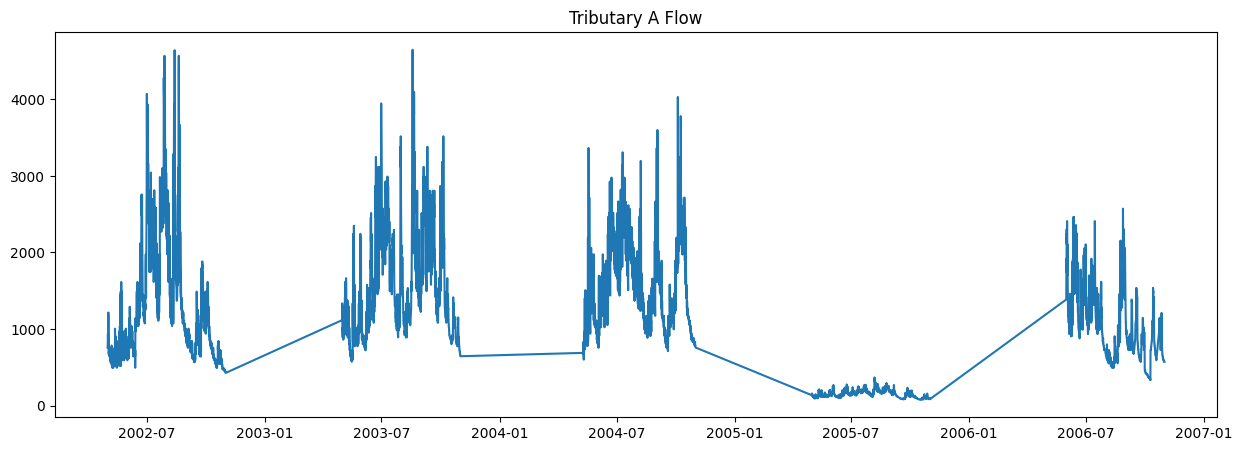

In [3]:
plt.figure(figsize=(15,5))
plt.plot(df['datetime'], df['tributary_A'])
plt.title('Tributary A Flow')
plt.show()

## Rolling Median

In [4]:
def rolling_median_anomalies(
    series,
    window=24,
    threshold_factor=3
):

    rolling_med = (
        series
        .rolling(
            window=window,
            center=True
        )
        .median()
    )

    residual = abs(
        series - rolling_med
    )

    threshold = (
        threshold_factor
        * residual.std()
    )

    anomalies = residual[
        residual > threshold
    ].index.tolist()

    return anomalies

## Detect Anomalies

In [5]:
anomalies_A = rolling_median_anomalies(
    df['tributary_A']
)

anomalies_B = rolling_median_anomalies(
    df['tributary_B']
)

print("A anomalies:", len(anomalies_A))
print("B anomalies:", len(anomalies_B))

A anomalies: 608
B anomalies: 514


## Visualize Detected Anomalies

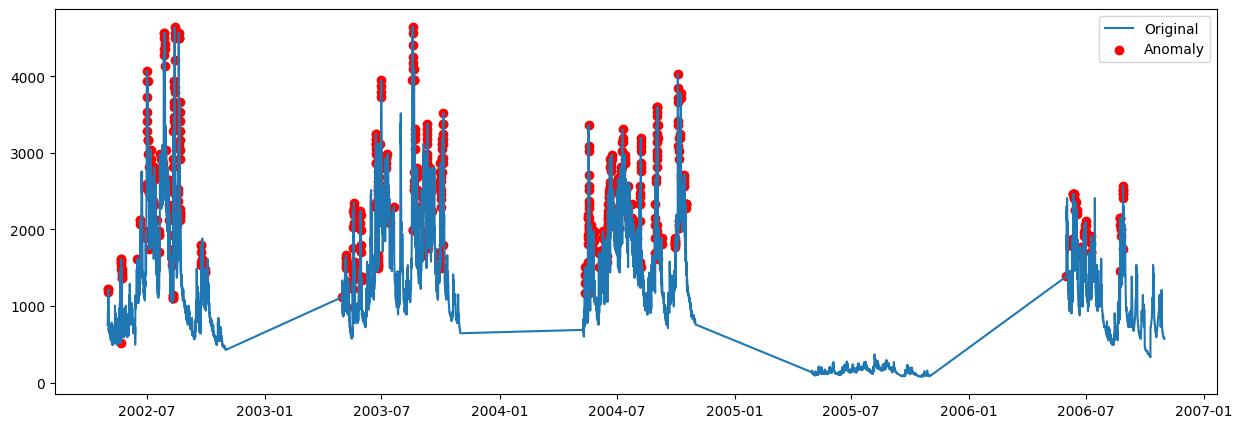

In [6]:
plt.figure(figsize=(15,5))

plt.plot(
    df['datetime'],
    df['tributary_A'],
    label='Original'
)

plt.scatter(
    df.loc[anomalies_A, 'datetime'],
    df.loc[anomalies_A, 'tributary_A'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.show()

## Replace Anomalies with NaN

In [7]:
df_clean = df.copy()

df_clean.loc[anomalies_A, 'tributary_A'] = np.nan
df_clean.loc[anomalies_B, 'tributary_B'] = np.nan

## Interpolate Missing Values

In [8]:
df_clean['tributary_A'] = (
    df_clean['tributary_A']
    .interpolate(method='linear')
)

df_clean['tributary_B'] = (
    df_clean['tributary_B']
    .interpolate(method='linear')
)

## Compare Before and After

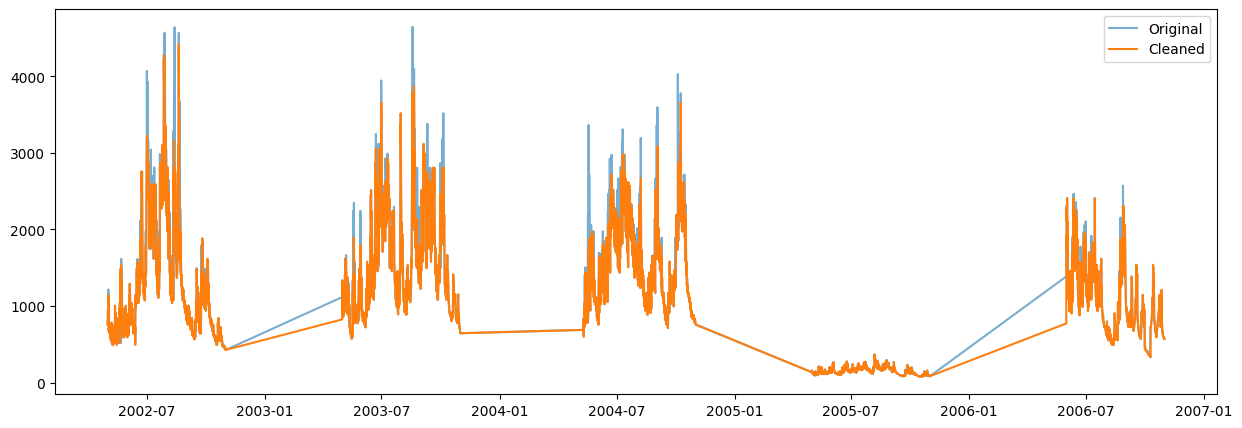

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    df['datetime'],
    df['tributary_A'],
    label='Original',
    alpha=0.6
)

plt.plot(
    df_clean['datetime'],
    df_clean['tributary_A'],
    label='Cleaned'
)

plt.legend()
plt.show()

## Clean Combined River

In [10]:
anomalies_C = rolling_median_anomalies(
    df['combined_river']
)

df_clean.loc[
    anomalies_C,
    'combined_river'
] = np.nan

df_clean['combined_river'] = (
    df_clean['combined_river']
    .interpolate()
)

## Save Cleaned Dataset

In [11]:
df_clean.rename(columns={
    'tributary_A': 'Tamen',
    'tributary_B': 'Daporizo',
    'combined_river': 'Gerukamukh'
}, inplace=True)

df_clean.to_excel('cleaned_rolling.xlsx',
index=False)

print('Saved: cleaned_rolling.xlsx')

print("Tributary A:", len(anomalies_A))

print("Tributary B:", len(anomalies_B))

print("Combined River:", len(anomalies_C))



for idx in anomalies_A[:5]:

    print("\nAnomaly at index:", idx)

    print(df.iloc[idx-3:idx+4])

Saved: cleaned_rolling.xlsx
Tributary A: 608
Tributary B: 514
Combined River: 688

Anomaly at index: 24
              datetime  tributary_A  tributary_B  combined_river
21 2002-05-01 22:00:00       784.50   454.016564         1508.74
22 2002-05-01 23:00:00       755.30   443.609909         1488.98
23 2002-05-02 00:00:00       755.30   443.609909         1488.00
24 2002-05-02 01:00:00      1216.34   443.609909         1459.51
25 2002-05-02 02:00:00      1216.34   443.609909         1449.72
26 2002-05-02 03:00:00      1179.66   433.326937         1439.96
27 2002-05-02 04:00:00      1143.55   433.326937         1401.13

Anomaly at index: 25
              datetime  tributary_A  tributary_B  combined_river
22 2002-05-01 23:00:00       755.30   443.609909         1488.98
23 2002-05-02 00:00:00       755.30   443.609909         1488.00
24 2002-05-02 01:00:00      1216.34   443.609909         1459.51
25 2002-05-02 02:00:00      1216.34   443.609909         1449.72
26 2002-05-02 03:00:00      1